In [1]:
## Installation required
## In qbraid we need to run the cell everytime we open a new session

!pip install qiskit[visualization]
# Use the following if you are on MacOS/zsh
#!pip install 'qiskit[visualization]'==1.1.0
!pip install qiskit_ibm_runtime
!pip install qiskit_aer
!pip install matplotlib
!pip install pylatexenc
!pip install prototype-zne

In [2]:
!pip install --upgrade qiskit-aer

In [3]:
import qiskit
qiskit.__version__

'2.5.1'

In [ ]:
## Import packages

#from math import pi
#import numpy as np
import time
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
#from qiskit.circuit import Gate
from qiskit_aer import AerSimulator, QasmSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

size = 4*4*8 #nb*h*k = 128
n = 6 #No. of key qubits to recover
x = 7 #x denotes the additional length of the key stream, other than key length, n. If key stream length is n+2, then x = 2

V = QuantumRegister(size) #128
X = QuantumRegister(size) #128
qr = QuantumRegister(288)
t = QuantumRegister(3)

r_key = QuantumRegister(n, 'r_key')
rev_ks = QuantumRegister(128, 'rev_ks') #n+x
r_ancilla = QuantumRegister(128, 'r_ancilla') #n+x
r_output = QuantumRegister(1, name = 'r_output')

num_qubit = 2*size+288+3+n+2*128+1 #It represents the total of qubits required
cr = ClassicalRegister(n) #128
qc = QuantumCircuit(V, X, qr, t, r_key, rev_ks, r_ancilla, r_output, cr)

In [5]:
num_qubits = qc.num_qubits
print("Number of qubits:", num_qubits)

Number of qubits: 810


In [ ]:
def algo1_org(qc, V, X):
    nb = 4; delta = 2; H = 4; W = 8
    #pi1 = ??; pi2 = ??; pi3 = ??; pi4 = ??
    pi1=[2 for i in range(H)]; pi2=[2 for i in range(H)]  #some dummy values
    for j in range(1, nb+1):
        if j%delta == 0:
            #algo2_org(j, pi1, pi2, H, W)
            for h in range(1, H+1):
                for k in range(1, W+1):
                    index_x = (h - 1) * W + k
                    index1 = (j - 1) * H * W + (h-1) * W + k
                    index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                    index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k
                    qc.ccx(V[index1-1], X[index2-1], X[index_x-1])
                    qc.cx(V[index3-1], X[index_x-1])
                    qc.swap(V[index1-1], X[index_x-1])
        for h in range(1, H+1):
            for k in range(1, W+1):
                index_k = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h - 1) * W + k
                index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                qc.swap(V[index1-1], X[index_k-1])
                qc.cx(V[index2-1], X[index_k-1])
                index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k
                qc.cx(V[index3-1], X[index_k-1])
        for h in range(1, H+1):
            for k in range(1, W+1):
                index_k = (h - 1) * W + k
                index_k1 = (h - 1) * W + (k - 2) % W #in place of 12
                qc.cx(X[index_k1-1], X[index_k-1])
                index_k2 = (h - 1) * W + (k + 5) % W #in place of 25
                index_k3 = (h - 1) * W + (k - 7) % W #in place of 27
                qc.cx(X[index_k2-1], X[index_k-1])
                qc.cx(X[index_k3-1], X[index_k-1])
                qc.swap(V[((j-1) * H * W + index_k)-1], X[index_k-1])
        for h in range(1, H+1):
            for k in range(1, W+1):
                index_x = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h-1) * W + k
                index2 = (j - 1) * H * W + ((h - pi1[h-1]) % W) + k #in place of (j - 1) * H * W + ((h - pi1[h-1]) % W - 1) * W + k
                qc.swap(V[index2-1], X[index_x-1])
                qc.swap(V[index1-1], X[index_x-1])
                qc.swap(V[index2-1], X[index_x-1])


def algo1_org_rev(qc, V, X):
    nb = 4; delta = 2; H = 4; W = 8
    #pi1 = ??; pi2 = ??; pi3 = ??; pi4 = ??
    pi1=[2 for i in range(H)]; pi2=[2 for i in range(H)]  #some dummy values
    for j in range(nb, 0, -1): # it was (1, nb+1)
        for h in range(H, 0, -1): # it was (1, H+1)
            for k in range(W, 0, -1): # it was (1, W+1)
                index_x = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h-1) * W + k
                index2 = (j - 1) * H * W + ((h - pi1[h-1]) % W) + k #in place of (j - 1) * H * W + ((h - pi1[h-1]) % W - 1) * W + k
                qc.swap(V[index2-1], X[index_x-1])
                qc.swap(V[index1-1], X[index_x-1])
                qc.swap(V[index2-1], X[index_x-1])
        for h in range(H, 0, -1): # it was (1, H+1)
            for k in range(W, 0, -1): # it was (1, W+1)
                index_k = (h - 1) * W + k
                index_k1 = (h - 1) * W + (k - 2) % W #in place of 12
                index_k2 = (h - 1) * W + (k + 5) % W #in place of 25
                index_k3 = (h - 1) * W + (k - 7) % W #in place of 27
                qc.swap(V[((j-1) * H * W + index_k)-1], X[index_k-1])
                qc.cx(X[index_k3-1], X[index_k-1])
                qc.cx(X[index_k2-1], X[index_k-1])
                qc.cx(X[index_k1-1], X[index_k-1])
        for h in range(H, 0, -1): # it was (1, H+1)
            for k in range(W, 0, -1): # it was (1, W+1)
                index_k = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h - 1) * W + k
                index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k                
                qc.cx(V[index2-1], X[index_k-1])
                qc.cx(V[index3-1], X[index_k-1])
                qc.swap(V[index1-1], X[index_k-1])              
        if j%delta == 0:
            #algo2_org(j, pi1, pi2, H, W)
            for h in range(H, 0, -1): # it was (1, H+1)
                for k in range(W, 0, -1): # it was (1, W+1)
                    index_x = (h - 1) * W + k
                    index1 = (j - 1) * H * W + (h-1) * W + k
                    index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                    index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k
                    qc.swap(V[index1-1], X[index_x-1])
                    qc.ccx(V[index1-1], X[index2-1], X[index_x-1])
                    qc.cx(V[index3-1], X[index_x-1])


In [7]:
#V_inp = "00001111"*16
#V_inp = "10011101110001010100111011111110100011010000010100011011011001001010000111001000000101101110110111001010100111000010011100111101"
#V_inp = "00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"
#V_inp = "11111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111"

#V_inp = "11100001110001010100111011111110100011010000010100011011011001001010000111001000000101101000110111001010000101000010011100111101"
# V_inp = "00110011001001111101010100001001010010010100111001011011111101110000111101000001100011010010000010001111100100000001000101110111"
V_inp = "1111101010100001001010010010100111001011011111101110000111101000001100011010010000010001111100100000001000101110111"

def V_init(qc, V, n, x):
    for i in range(size-(n+x)):
        if(V_inp[i] =="1"):
            qc.x(V[i+(n+x)])
#V_inp = "00001111"*16

In [8]:
def cipher(qc, V, n, x):
    for i in range(n): 
        qc.cx(r_key[i], V[i])
    for i in range(x): 
        qc.x(V[i+n])

In [9]:
def my_oracle(qc, r_key, r_ancilla, rev_ks, V, r_output, n, x):
    #Preparing key in a superposition state
    cipher(qc, V, n, x)
    algo1_org(qc, V, X)
    
    #Checking whether the generated key stream is equal to the given key stream
    for i in range(128): #n+x
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(V[i], r_ancilla[i]) 
        qc.x(r_ancilla[i])
        
    #Set 'output' bit if the key stream is matched
    qc.mcx(r_ancilla, r_output)
    
    qc.barrier()
    
    #Uncompute to reset ancilla & key stream qubits
    for i in range(128): #n+x
        qc.x(r_ancilla[i])
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(V[i], r_ancilla[i]) 
    qc.barrier()
    
    algo1_org_rev(qc, V, X)
    cipher(qc, V, n, x)
    qc.barrier()
        

In [10]:
#The diffuser function is available in Qiskit; Courtesey: https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/grover.ipynb
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    #nqubits = nqubits - 2
    #Apply transformation |s> -> |00...0> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #Apply transformation |00...0> -> |11...1> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)    
    #Do multi-controlled Z gate
    qc.h(nqubits - 1)
    qc.mcx(list(range(nqubits - 1)), nqubits - 1) #multi-controlled Toffoli; replaced with qc.mct(list(range(nqubits - 1)), nqubits - 1)
    qc.h(nqubits - 1)
    #Apply transformation |11...1> -> |00...0> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)
    #Apply transformation |00...0> -> |s> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #We will return the diffuser as a gate
    U_s = qc.to_gate()
    #U_s.name = "U$_s$"
    return U_s

In [11]:
# Loading known key stream for an unknown Key
ks_actual = '11000110011000010001111111111010011101001011010100100101000111111000100000011100001000100001000110000010001110110110101000010110' 
# Key: '000000'

for i in range(128): #n+x
    if (ks_actual[i] == "1"):
        qc.x(rev_ks[i])

for i in range(n):
    qc.h(r_key[i])

#Preparing output qubit
qc.x(r_output)
qc.h(r_output)
qc.barrier()

start = time.perf_counter() #time.process_time()

V_init(qc, V, n, x)

for i in range(2):
    my_oracle(qc, r_key, r_ancilla, rev_ks, V, r_output, n, x)
    #qc.barrier()
    qc.append(diffuser(n), r_key)
    #qc.barrier()

qc.measure(r_key, cr) 
print("Circuit depth: ", qc.depth())


Circuit depth:  1357


In [12]:
# Simulate the quantum circuit
backend = AerSimulator(method='matrix_product_state') # 'automatic' or 'matrix_product_state', 'density_matrix' (but only 'matrix_product_state' is working for select = 7; for other options simulation fails)
n_o_shots = 200 #1024
qcd = qc.decompose(reps=5)
result = backend.run(qcd, shots=n_o_shots).result()
print("Wall-time elapsed (in sec):", time.perf_counter() - start)
## Plot results
counts = result.get_counts()
print (counts)

Wall-time elapsed (in sec): 52340.60406419996
{'011100': 2, '001011': 1, '100010': 3, '111100': 2, '100100': 3, '001101': 3, '001100': 7, '100011': 3, '111101': 4, '011001': 1, '110111': 2, '000000': 67, '101111': 1, '000110': 4, '011111': 4, '001010': 2, '100001': 3, '111111': 2, '101100': 4, '000011': 3, '010111': 3, '101011': 5, '000010': 4, '111011': 2, '001110': 3, '100101': 2, '101001': 1, '110110': 1, '101010': 3, '000001': 6, '011011': 4, '010011': 4, '011110': 4, '010110': 2, '010001': 1, '010100': 2, '011101': 4, '111010': 1, '100110': 1, '001111': 1, '101110': 2, '000101': 1, '111001': 3, '001000': 1, '001001': 1, '010101': 3, '000111': 1, '110000': 3, '100111': 4, '111000': 1, '010010': 2, '010000': 1, '011010': 1, '100000': 1}


Key is : 000000 with probability = 0.335 and count = 67


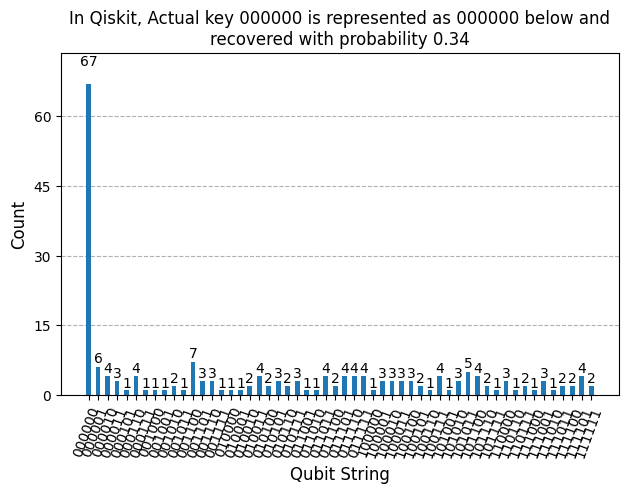

In [13]:
b, c = max(counts.items(), key=lambda x: x[1])
print("Key is :", b[::-1], "with probability =", c/n_o_shots, "and count =", c)

%matplotlib inline
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

figure = plot_histogram(counts, title = "In Qiskit, Actual key {0} is represented as {1} below and\nrecovered with probability {2:.2f}".format(b[::-1],b,c/n_o_shots))
# Label the axes
ax = figure.gca()  # Get the current axis
ax.set_xlabel('Qubit String', fontsize=12)  # Set x-axis label
ax.set_ylabel('Count', fontsize=12)  # Set y-axis label

# Save the plot as an image
figure.savefig("histogram.png")